# 잠실 2024 비교

In [16]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

project_root = Path.cwd().resolve()
for candidate in [project_root, project_root.parent]:
    if (candidate / "Data").exists():
        project_root = candidate
        break

holiday_dates = pd.to_datetime([
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01",
    "2024-04-10",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09",
    "2024-12-25",
]).normalize()

canonical_hours = [f"{hour:02d}시" for hour in range(6, 24)]
plot_hours = canonical_hours[1:]


def normalize_col(name):
    return re.sub(r"\s+", "", str(name)).strip()


def label_day_type(series):
    dt = pd.to_datetime(series).dt.normalize()
    is_holiday = (dt.dt.dayofweek >= 5) | dt.isin(holiday_dates)
    return np.where(is_holiday, "휴일", "평일")


def minmax_scale(series):
    s = series.astype(float)
    min_value = s.min()
    max_value = s.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(0.0, index=s.index, dtype=float)
    return (s - min_value) / (max_value - min_value)


subway_path = project_root / "Data/Metro/jamsil_metro_2024.csv"
subway_df = pd.read_csv(subway_path)
subway_df.columns = [str(col).strip() for col in subway_df.columns]
subway_date_col = next(col for col in subway_df.columns if "날짜" in normalize_col(col))
subway_direction_col = next(col for col in subway_df.columns if "구분" in normalize_col(col))
subway_hour_cols = [col for col in subway_df.columns if re.match(r"^\d{2}시-\d{2}시$", normalize_col(col))][:18]
subway_hour_map = {col: f"{int(normalize_col(col)[:2]):02d}시" for col in subway_hour_cols}
subway_df[subway_date_col] = pd.to_datetime(subway_df[subway_date_col])
subway_df["day_type"] = label_day_type(subway_df[subway_date_col])

subway_daily_df = (
    subway_df
    .groupby([subway_date_col, "day_type", subway_direction_col], as_index=False)[subway_hour_cols]
    .sum()
)
subway_long_df = subway_daily_df.melt(
    id_vars=[subway_date_col, "day_type", subway_direction_col],
    value_vars=subway_hour_cols,
    var_name="hour_col",
    value_name="value",
)
subway_long_df["hour_label"] = subway_long_df["hour_col"].map(subway_hour_map)
subway_max_daily_df = (
    subway_long_df
    .groupby([subway_date_col, "day_type", "hour_label"], as_index=False)["value"]
    .max()
    .rename(columns={"value": "subway_max"})
)
subway_profile_df = (
    subway_max_daily_df
    .groupby(["day_type", "hour_label"], as_index=False)["subway_max"]
    .median()
)
subway_profile_df["hour_order"] = subway_profile_df["hour_label"].str.extract(r"(\d+)").astype(int)

traffic_dir = project_root / "Data/Trafficdata"
traffic_frames = []
for month in range(1, 13):
    month_files = sorted(traffic_dir.glob(f"{month:02d}*2024*.xlsx"))
    if not month_files:
        raise FileNotFoundError(f"Traffic file not found for month={month:02d}")
    traffic_file = month_files[0]
    excel_file = pd.ExcelFile(traffic_file)
    loaded_df = None

    for sheet_name in excel_file.sheet_names:
        for header_row in range(3):
            try:
                raw_df = pd.read_excel(traffic_file, sheet_name=sheet_name, header=header_row)
            except Exception:
                continue

            raw_df.columns = [str(col).strip() for col in raw_df.columns]
            normalized_cols = {col: normalize_col(col) for col in raw_df.columns}
            location_col = next((col for col, norm in normalized_cols.items() if "지점명" in norm or "지점명칭" in norm), None)
            date_col = next((col for col, norm in normalized_cols.items() if norm == "일자" or "날짜" in norm), None)
            direction_col = next((col for col, norm in normalized_cols.items() if "방향" in norm), None)
            if not location_col or not date_col or not direction_col:
                continue

            hour_map = {}
            for hour in range(6, 24):
                candidates = [
                    col for col, norm in normalized_cols.items()
                    if norm in {f"{hour:02d}시", f"{hour}시"}
                ]
                if not candidates:
                    hour_map = {}
                    break
                hour_map[f"{hour:02d}시"] = candidates[0]

            if len(hour_map) != len(canonical_hours):
                continue

            bridge_mask = raw_df[location_col].astype(str).map(lambda x: normalize_col(x) == "잠실대교")
            if not bridge_mask.any():
                continue

            loaded_df = raw_df.loc[bridge_mask, [date_col, direction_col] + list(hour_map.values())].copy()
            loaded_df = loaded_df.rename(columns={date_col: "일자", direction_col: "방향", **{value: key for key, value in hour_map.items()}})
            loaded_df["month"] = month
            traffic_frames.append(loaded_df)
            break
        if loaded_df is not None:
            break

    if loaded_df is None:
        raise RuntimeError(f"잠실대교 row not found in {traffic_file.name}")

traffic_df = pd.concat(traffic_frames, ignore_index=True)
traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
traffic_df["day_type"] = label_day_type(traffic_df["일자"])
for col in canonical_hours:
    traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce").fillna(0)

traffic_daily_df = (
    traffic_df
    .groupby(["일자", "day_type", "방향"], as_index=False)[canonical_hours]
    .sum()
)
traffic_long_df = traffic_daily_df.melt(
    id_vars=["일자", "day_type", "방향"],
    value_vars=canonical_hours,
    var_name="hour_label",
    value_name="value",
)
traffic_max_daily_df = (
    traffic_long_df
    .groupby(["일자", "day_type", "hour_label"], as_index=False)["value"]
    .max()
    .rename(columns={"value": "traffic_max"})
)
traffic_profile_df = (
    traffic_max_daily_df
    .groupby(["day_type", "hour_label"], as_index=False)["traffic_max"]
    .median()
)
traffic_profile_df["hour_order"] = traffic_profile_df["hour_label"].str.extract(r"(\d+)").astype(int)

target_path = project_root / "Data/jamsil_Target_2024.csv"
target_df = pd.read_csv(target_path)
time_col = next(col for col in target_df.columns if "시간대" in normalize_col(col))
in_col = next(col for col in target_df.columns if "입차" in normalize_col(col))
out_col = next(col for col in target_df.columns if "출차" in normalize_col(col))

target_df["timestamp"] = pd.to_datetime(target_df[time_col], errors="coerce")
if target_df["timestamp"].isna().any():
    target_df["timestamp"] = pd.to_datetime(target_df[time_col].astype(str), format="%Y-%m-%d %H", errors="coerce")

target_df = target_df[target_df["timestamp"].dt.hour.between(6, 23)].copy()
target_df["date"] = target_df["timestamp"].dt.normalize()
target_df["day_type"] = label_day_type(target_df["date"])
target_df["hour_order"] = target_df["timestamp"].dt.hour
target_df["hour_label"] = target_df["hour_order"].map(lambda hour: f"{hour:02d}시")
target_df[[in_col, out_col]] = target_df[[in_col, out_col]].apply(pd.to_numeric, errors="coerce").fillna(0)

target_hourly_df = (
    target_df
    .groupby(["date", "day_type", "hour_label", "hour_order"], as_index=False)[[in_col, out_col]]
    .sum()
)
target_hourly_df["target_max"] = target_hourly_df[[in_col, out_col]].max(axis=1)
target_profile_df = (
    target_hourly_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["target_max"]
    .median()
    .sort_values(["day_type", "hour_order"])
)

compare_df = (
    subway_profile_df
    .merge(traffic_profile_df, on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(target_profile_df[["day_type", "hour_label", "hour_order", "target_max"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)

scaled_parts = []
for day_type, group in compare_df.groupby("day_type", sort=False):
    scaled_group = group.sort_values("hour_order").copy()
    scaled_group["subway_scaled"] = minmax_scale(scaled_group["subway_max"])
    scaled_group["traffic_scaled"] = minmax_scale(scaled_group["traffic_max"])
    scaled_group["combined_scaled"] = (scaled_group["subway_scaled"] + scaled_group["traffic_scaled"]) / 2
    scaled_group["target_scaled"] = minmax_scale(scaled_group["target_max"])
    scaled_group["subway_shifted"] = scaled_group["subway_scaled"].shift(1)
    scaled_group["traffic_shifted"] = scaled_group["traffic_scaled"].shift(1)
    scaled_group["combined_shifted"] = scaled_group["combined_scaled"].shift(1)
    scaled_parts.append(scaled_group)

compare_scaled_df = pd.concat(scaled_parts, ignore_index=True)
compare_shifted_df = (
    compare_scaled_df.loc[compare_scaled_df["hour_order"].between(7, 23), [
        "day_type",
        "hour_label",
        "hour_order",
        "subway_shifted",
        "traffic_shifted",
        "combined_shifted",
        "target_scaled",
    ]]
    .reset_index(drop=True)
)

rmse_rows = []
for day_type, group in compare_shifted_df.groupby("day_type", sort=False):
    rmse_rows.append({
        "day_type": day_type,
        "subway_rmse": np.sqrt(((group["subway_shifted"] - group["target_scaled"]) ** 2).mean()),
        "traffic_rmse": np.sqrt(((group["traffic_shifted"] - group["target_scaled"]) ** 2).mean()),
        "combined_rmse": np.sqrt(((group["combined_shifted"] - group["target_scaled"]) ** 2).mean()),
    })

rmse_summary_df = pd.DataFrame(rmse_rows)

hour_validation_df = pd.DataFrame({
    "dataset": ["subway", "traffic", "target"],
    "source_hour_columns": [
        ", ".join(subway_hour_cols),
        ", ".join(canonical_hours),
        ", ".join(canonical_hours),
    ],
    "plot_hour_labels": [", ".join(plot_hours)] * 3,
})

date_split_validation_df = pd.DataFrame([
    {
        "dataset": "subway",
        "평일_date_count": subway_max_daily_df.loc[subway_max_daily_df["day_type"] == "평일", subway_date_col].nunique(),
        "휴일_date_count": subway_max_daily_df.loc[subway_max_daily_df["day_type"] == "휴일", subway_date_col].nunique(),
    },
    {
        "dataset": "traffic",
        "평일_date_count": traffic_max_daily_df.loc[traffic_max_daily_df["day_type"] == "평일", "일자"].nunique(),
        "휴일_date_count": traffic_max_daily_df.loc[traffic_max_daily_df["day_type"] == "휴일", "일자"].nunique(),
    },
    {
        "dataset": "target",
        "평일_date_count": target_hourly_df.loc[target_hourly_df["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": target_hourly_df.loc[target_hourly_df["day_type"] == "휴일", "date"].nunique(),
    },
])

print("hour validation")
display(hour_validation_df)
print("date split validation")
display(date_split_validation_df)
print("shifted/scaled hourly dataframe")
display(compare_shifted_df)
print("rmse summary")
display(rmse_summary_df)


hour validation


,dataset,source_hour_columns,plot_hour_labels
0,subway,"06시-07시, 07시-08시, 08시-09시, 09시-10시, 10시-11시, 1...","07시, 08시, 09시, 10시, 11시, 12시, 13시, 14시, 15시, 1..."
1,traffic,"06시, 07시, 08시, 09시, 10시, 11시, 12시, 13시, 14시, 1...","07시, 08시, 09시, 10시, 11시, 12시, 13시, 14시, 15시, 1..."
2,target,"06시, 07시, 08시, 09시, 10시, 11시, 12시, 13시, 14시, 1...","07시, 08시, 09시, 10시, 11시, 12시, 13시, 14시, 15시, 1..."


date split validation


,dataset,평일_date_count,휴일_date_count
0,subway,247,119
1,traffic,247,119
2,target,247,119


shifted/scaled hourly dataframe


,day_type,hour_label,hour_order,subway_shifted,traffic_shifted,combined_shifted,target_scaled
0,평일,07시,7,0.051899,0.672005,0.361952,0.183673
1,평일,08시,8,0.400195,1.000000,0.700097,0.622449
2,평일,09시,9,0.955501,0.951957,0.953729,1.000000
3,평일,10시,10,0.639338,0.780546,0.709942,0.489796
4,평일,11시,11,0.361052,0.737248,0.549150,0.367347
5,평일,12시,12,0.315190,0.612100,0.463645,0.326531
6,평일,13시,13,0.275463,0.518980,0.397221,0.265306
7,평일,14시,14,0.271081,0.569395,0.420238,0.295918
8,평일,15시,15,0.269328,0.635824,0.452576,0.316327
9,평일,16시,16,0.351217,0.651839,0.501528,0.377551


rmse summary


,day_type,subway_rmse,traffic_rmse,combined_rmse
0,평일,0.092702,0.258246,0.124514
1,휴일,0.173226,0.170890,0.157641


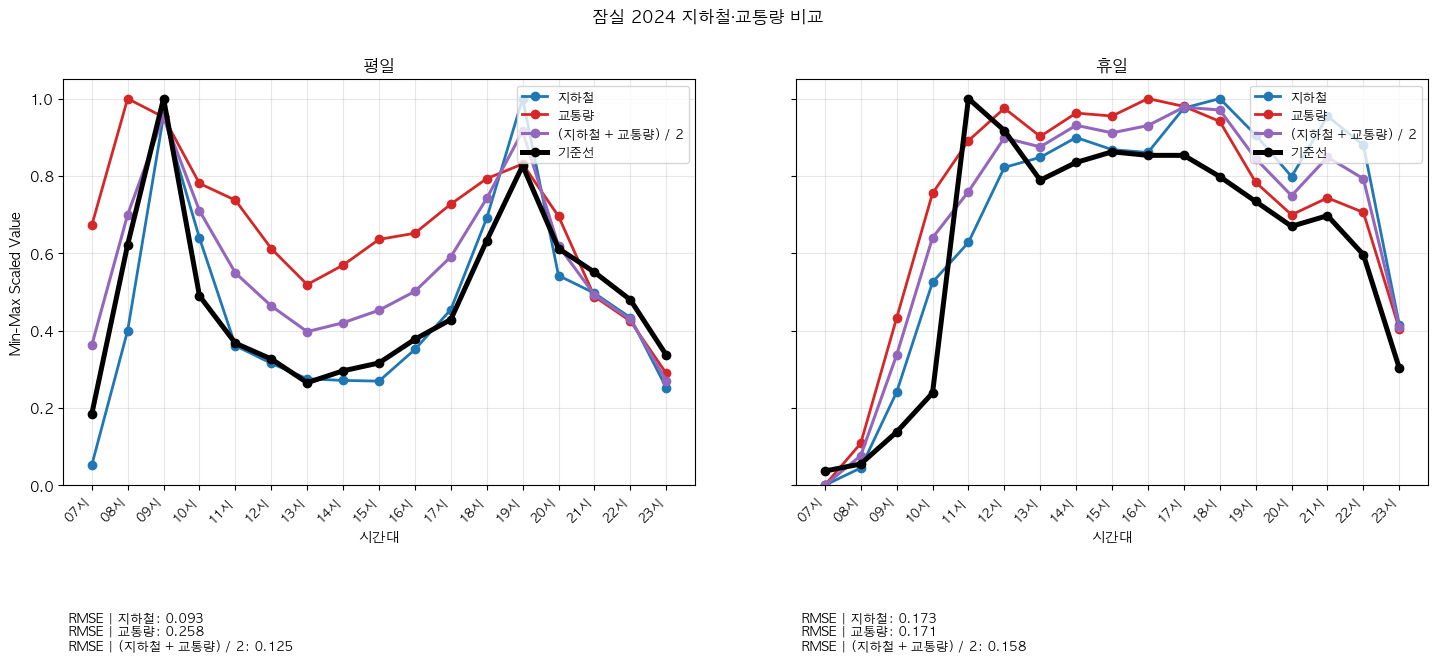

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.0), sharey=True)
plot_order = ["평일", "휴일"]
line_specs = [
    ("subway_shifted", "지하철", "#1f77b4", 2.0),
    ("traffic_shifted", "교통량", "#d62728", 2.0),
    ("combined_shifted", "(지하철 + 교통량) / 2", "#9467bd", 2.2),
    ("target_scaled", "기준선", "black", 3.6),
]

x_positions = range(len(plot_hours))

for ax, day_type in zip(axes, plot_order):
    subset = compare_shifted_df[compare_shifted_df["day_type"] == day_type].sort_values("hour_order")
    rmse_row = rmse_summary_df[rmse_summary_df["day_type"] == day_type].iloc[0]

    for col, label, color, width in line_specs:
        ax.plot(x_positions, subset[col], marker="o", linewidth=width, color=color, label=label)

    rmse_text = (
        f"RMSE | 지하철: {rmse_row['subway_rmse']:.3f}\n"
        f"RMSE | 교통량: {rmse_row['traffic_rmse']:.3f}\n"
        f"RMSE | (지하철 + 교통량) / 2: {rmse_row['combined_rmse']:.3f}"
    )

    ax.set_title(day_type)
    ax.set_xlabel("시간대")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    ax.text(0.01, -0.31, rmse_text, transform=ax.transAxes, ha="left", va="top", fontsize=9)

axes[0].set_ylabel("Min-Max Scaled Value")
fig.suptitle("잠실 2024 지하철·교통량 비교")
fig.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.30, wspace=0.16)
plt.show()

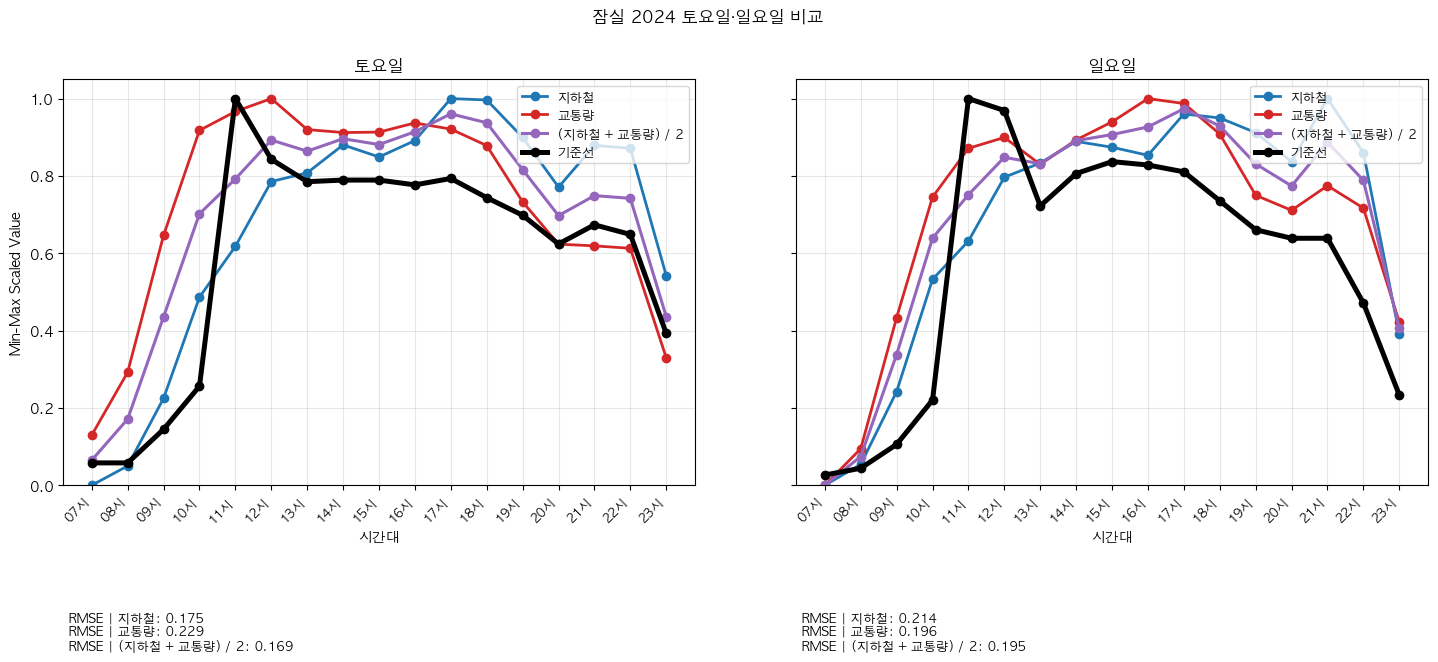

In [18]:
weekend_order = ["토요일", "일요일"]
weekday_name_map = {5: "토요일", 6: "일요일"}

subway_weekend_profile_df = subway_max_daily_df.copy()
subway_weekend_profile_df["weekday"] = pd.to_datetime(subway_weekend_profile_df[subway_date_col]).dt.dayofweek
subway_weekend_profile_df = subway_weekend_profile_df[subway_weekend_profile_df["weekday"].isin(weekday_name_map)].copy()
subway_weekend_profile_df["weekday_name"] = subway_weekend_profile_df["weekday"].map(weekday_name_map)
subway_weekend_profile_df = (
    subway_weekend_profile_df
    .groupby(["weekday_name", "hour_label"], as_index=False)["subway_max"]
    .median()
)
subway_weekend_profile_df["hour_order"] = subway_weekend_profile_df["hour_label"].str.extract(r"(\d+)").astype(int)

traffic_weekend_profile_df = traffic_max_daily_df.copy()
traffic_weekend_profile_df["weekday"] = pd.to_datetime(traffic_weekend_profile_df["일자"]).dt.dayofweek
traffic_weekend_profile_df = traffic_weekend_profile_df[traffic_weekend_profile_df["weekday"].isin(weekday_name_map)].copy()
traffic_weekend_profile_df["weekday_name"] = traffic_weekend_profile_df["weekday"].map(weekday_name_map)
traffic_weekend_profile_df = (
    traffic_weekend_profile_df
    .groupby(["weekday_name", "hour_label"], as_index=False)["traffic_max"]
    .median()
)
traffic_weekend_profile_df["hour_order"] = traffic_weekend_profile_df["hour_label"].str.extract(r"(\d+)").astype(int)

target_weekend_profile_df = target_hourly_df.copy()
target_weekend_profile_df["weekday"] = pd.to_datetime(target_weekend_profile_df["date"]).dt.dayofweek
target_weekend_profile_df = target_weekend_profile_df[target_weekend_profile_df["weekday"].isin(weekday_name_map)].copy()
target_weekend_profile_df["weekday_name"] = target_weekend_profile_df["weekday"].map(weekday_name_map)
target_weekend_profile_df = (
    target_weekend_profile_df
    .groupby(["weekday_name", "hour_label", "hour_order"], as_index=False)["target_max"]
    .median()
)

weekend_compare_df = (
    subway_weekend_profile_df
    .merge(traffic_weekend_profile_df, on=["weekday_name", "hour_label", "hour_order"], how="inner")
    .merge(target_weekend_profile_df[["weekday_name", "hour_label", "hour_order", "target_max"]], on=["weekday_name", "hour_label", "hour_order"], how="inner")
    .sort_values(["weekday_name", "hour_order"])
    .reset_index(drop=True)
)

weekend_scaled_parts = []
for weekday_name, group in weekend_compare_df.groupby("weekday_name", sort=False):
    scaled_group = group.sort_values("hour_order").copy()
    scaled_group["subway_scaled"] = minmax_scale(scaled_group["subway_max"])
    scaled_group["traffic_scaled"] = minmax_scale(scaled_group["traffic_max"])
    scaled_group["combined_scaled"] = (scaled_group["subway_scaled"] + scaled_group["traffic_scaled"]) / 2
    scaled_group["target_scaled"] = minmax_scale(scaled_group["target_max"])
    scaled_group["subway_shifted"] = scaled_group["subway_scaled"].shift(1)
    scaled_group["traffic_shifted"] = scaled_group["traffic_scaled"].shift(1)
    scaled_group["combined_shifted"] = scaled_group["combined_scaled"].shift(1)
    weekend_scaled_parts.append(scaled_group)

weekend_compare_shifted_df = (
    pd.concat(weekend_scaled_parts, ignore_index=True)
    .loc[lambda df: df["hour_order"].between(7, 23), [
        "weekday_name",
        "hour_label",
        "hour_order",
        "subway_shifted",
        "traffic_shifted",
        "combined_shifted",
        "target_scaled",
    ]]
    .reset_index(drop=True)
)

weekend_rmse_summary_df = pd.DataFrame([
    {
        "weekday_name": weekday_name,
        "subway_rmse": np.sqrt(((group["subway_shifted"] - group["target_scaled"]) ** 2).mean()),
        "traffic_rmse": np.sqrt(((group["traffic_shifted"] - group["target_scaled"]) ** 2).mean()),
        "combined_rmse": np.sqrt(((group["combined_shifted"] - group["target_scaled"]) ** 2).mean()),
    }
    for weekday_name, group in weekend_compare_shifted_df.groupby("weekday_name", sort=False)
])

fig, axes = plt.subplots(1, 2, figsize=(15, 7.0), sharey=True)
line_specs = [
    ("subway_shifted", "지하철", "#1f77b4", 2.0),
    ("traffic_shifted", "교통량", "#d62728", 2.0),
    ("combined_shifted", "(지하철 + 교통량) / 2", "#9467bd", 2.2),
    ("target_scaled", "기준선", "black", 3.6),
]

x_positions = range(len(plot_hours))

for ax, weekday_name in zip(axes, weekend_order):
    subset = weekend_compare_shifted_df[weekend_compare_shifted_df["weekday_name"] == weekday_name].sort_values("hour_order")
    rmse_row = weekend_rmse_summary_df[weekend_rmse_summary_df["weekday_name"] == weekday_name].iloc[0]

    for col, label, color, width in line_specs:
        ax.plot(x_positions, subset[col], marker="o", linewidth=width, color=color, label=label)

    rmse_text = (
        f"RMSE | 지하철: {rmse_row['subway_rmse']:.3f}\n"
        f"RMSE | 교통량: {rmse_row['traffic_rmse']:.3f}\n"
        f"RMSE | (지하철 + 교통량) / 2: {rmse_row['combined_rmse']:.3f}"
    )

    ax.set_title(weekday_name)
    ax.set_xlabel("시간대")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    ax.text(0.01, -0.31, rmse_text, transform=ax.transAxes, ha="left", va="top", fontsize=9)

axes[0].set_ylabel("Min-Max Scaled Value")
fig.suptitle("잠실 2024 토요일·일요일 비교")
fig.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.30, wspace=0.16)
plt.show()
